In [9]:
import numpy as np 
import qutip as qt
import ufss as uf
import matplotlib.pyplot as plt

# 2. La spectroscopie 2D
from qudpy.Classes import System
import qudpy.plot_functions as pf

# Physic constant and definition of parameter


In [ ]:
hbar = 0.658211951 # hbar in eV*fs

E_elec= 1.5 # d-d transition energy
E_elec_2= 1.6
E_vib = 0.020 # Phonon énergie

S=0.01 # Facteur de Hunag-Rhys (For Frank-condon approximation)
lambda_HT= 0.5 # Coupling parameter Herzberg-Teller modele

w_e = E_elec  #electronic transition frequency
w_v = E_vib  #phonon transition frequency
N_fock = 2 # number of phonon mode. 

# Operator definition 

1. qt.tensor $\newline$ This function combines operators acting on different subsystems to create a global operator.

- Example: If space A has dimension $N$ and space B has dimension $M$, qt.tensor(A, B) creates a matrix of dimension $(N \times M)$.

2. Bosonic Mode OperatorsThese lines define the annihilation operator for a bosonic mode.

- qt.destroy(N_fock): $\newline$
Creates the annihilation operator $a$ in a Fock space truncated to $N_{fock}$ states.
- qt.qeye(2):  $\newline$
The identity matrix of size 2. It serves as a "placeholder" meaning: "do nothing to the first system (the spin)."
- a = qt.tensor(qt.qeye(2), qt.destroy(N_fock)):  $\newline$
The global operator $a$ acting on the $(\text{spin}) \otimes (\text{boson})$ space.
- a.dag(): $\newline$
Method that calculates the Hermitian adjoint ($a^\dagger$).

- mu= 1.0 * (sp+sm): $\newline$
dipolar operator in frank-condon approximation



In [11]:
a = qt.tensor(qt.qeye(2), qt.destroy(N_fock))
adag = a.dag()

# Opérateur électronique
sm = qt.tensor(qt.destroy(2), qt.qeye(N_fock))
sp = sm.dag()
sz = qt.tensor(qt.sigmaz(),qt.qeye(N_fock))

#Dipolair operator (Frank Condon approximation)
mu=1.0 * (sp + sm)

#Dipolar operator (Herzberg-Teller effect)
mu_HT = lambda_HT * (a + adag) * (sp+sm)

mu_ladder= adag + sm
mu_coupling = sp + sm + adag + a

# Hamiltonian

In [ ]:
H_elec =w_e * sp * sm 

H_vib = w_v *adag*a

# Le terme de couplage qui décale le potentiel pour l'état excité :
H_couplage = w_v * np.sqrt(S) * (a + adag) * (sp*sm)




H_total = H_elec + H_vib + H_couplage
print (H_total)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dia, isherm=True
Qobj data =
[[0.         0.         0.         0.        ]
 [0.         0.03038535 0.         0.        ]
 [0.         0.         1.5        0.002     ]
 [0.         0.         0.002      1.53038535]]


 # Dissipation (Lindblad operator)

 

In [13]:
kappa_elec = 0.02 # Taux de relaxation de l'électron 

kappa_vib = 0.05 # Taux de relaxation du phonon (déphasage vibratoire)

T = 20 # temperature en K
kB = 8.617333262e-5  # eV/K
beta = 1 / (T * kB)

# Population thermique du phonon à temperature choisi
n_th_vib= 1/(np.exp(E_vib * beta)-1)

# Matrice de dissipation (linblad)
c_ops = [
    #Relaxation électronique (vers le  fonamental pure)
    np.sqrt(kappa_elec)* sm,
    # Déphasage pur électronique (si nécessaire pour élargir)
    np.sqrt(kappa_elec *2)*sp*sm,
    # Relaxation du phonon (avec le bain thermique)
    np.sqrt(kappa_vib * n_th_vib + 1) * adag,
    #excitation themrique du phonon 
    np.sqrt(kappa_vib * n_th_vib) * adag
]

# Density Matrix

In [14]:
rho_elec = qt.fock_dm(2,0)
rho_vib = qt.thermal_dm(N_fock,n_th_vib)
rho = qt.tensor(rho_elec,rho_vib)

# Impulsion sequence

In [15]:
sys = System(H=H_total, rho=rho, a=mu_ladder, u=mu_coupling, c_ops=c_ops, diagonalize=True)

# Paramétrage des délai temporelles (En femtosecondes)
# Pour résoudre un pohon de 103 fs, on échantillone environ sur 300fs

res_fs= 10 #résolution temporelle (pas de 3fs)
N_t1 = 100 # Nombre de pas durant le délai t1 (total= 300fs)
N_t3 = 100 # Nombre de pas durant la détection t3 (total = 300fs)
t2_attente = 0 #Temps de population (T) fixé à 0 fs pour commencer

time_delays = [N_t1,t2_attente, N_t3]
scan_id = [0,2] # On effectue la transformée de Fourier sur t1 (index 0 ) et t3 (index 2)


diagonalizing Hamiltonian and transforming everything into eigen-basis except rho
system initialized


# Feynmann Diagram

In [16]:
DG = uf.DiagramGenerator
R3rd = DG()
dummy_times = [0, 100, 200, 300]
t_pulse = np.array([-1, 1])
R3rd.efield_times = [t_pulse] * 4

# --- 1. Diagrammes Rephasing (R1, R2, R3) ---
# Phase discrimination pour k_I = -k1 + k2 + k3
R3rd.set_phase_discrimination([(0, 1), (1, 0), (1, 0)])
[R3, R1, R2] = R3rd.get_diagrams(dummy_times)
rephasing = [R1, R2, R3]

# --- 2. Diagrammes Non-Rephasing (R4, R5, R6) ---
# Phase discrimination pour k_II = +k1 - k2 + k3
R3rd.set_phase_discrimination([(1, 0), (0, 1), (1, 0)])
[R6, R4, R5] = R3rd.get_diagrams(dummy_times)
nonrephasing = [R4, R5, R6]
response_list = []
total_diagrams = rephasing + nonrephasing

# Dynamic 

In [17]:
print("Calcul de la dynamique quantique en cours...")
for k in range(6):
    # L'argument r=res_fs dicte le pas temporel à la librairie
    states, t1, t2, dipole = sys.coherence2d(time_delays, total_diagrams[k], scan_id, r=res_fs, parallel=False)
    response_list.append(1j * dipole)

Calcul de la dynamique quantique en cours...
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors


C:\Users\MathieuDesmarais\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


second scan done
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done


# Fourier Transform 

In [18]:
spectra_list, extent, f1, f2 = sys.spectra(response_list, resolution=res_fs)


# Signal extracting 

In [19]:
rephasing_spectra = spectra_list[:3]
rephasing_spectra.append(np.sum(spectra_list[:3], 0)) # La somme donne le signal Rephasing macroscopique

nonrephasing_spectra = spectra_list[3:]
nonrephasing_spectra.append(np.sum(spectra_list[3:], 0))

# Plot of the 2D map 

In [20]:
"""
print("Génération de la figure...")
# Affichage du signal Rephasing (le plus instructif pour l'élargissement inhomogène)




pf.silva_plot(rephasing_spectra, f1,f2, labels=['E emission', 'E absorption'],
              title_list=['$R_1$', '$R_2$', '$R_3$', '$R_{rephasing}$'], scale='linear', color_map='PuOr',
              interpolation='spline36', center_scale=False, plot_sum=False, plot_quadrant='4', invert_y=False,
              diagonals=[True, True])
quit()
#Example of the zoom feature
rephasing_spectra = spectra_list[:3]
rephasing_spectra.append(np.sum(spectra_list[:3], 0))
pf.silva_plot(rephasing_spectra, f1,f2, labels=['E emission', 'E absorption'],
              title_list=['$R_1$', '$R_2$', '$R_3$', '$R_{rephasing}$'], scale='linear', color_map='PuOr',
              interpolation='spline36', center_scale=False, plot_sum=False, plot_quadrant='Zoom', invert_y=False,
              diagonals=[True, True],Zoom_coor = [1.5,3,-3,-1.5])
"""


'\nprint("Génération de la figure...")\n# Affichage du signal Rephasing (le plus instructif pour l\'élargissement inhomogène)\n\n\n\n\npf.silva_plot(rephasing_spectra, f1,f2, labels=[\'E emission\', \'E absorption\'],\n              title_list=[\'$R_1$\', \'$R_2$\', \'$R_3$\', \'$R_{rephasing}$\'], scale=\'linear\', color_map=\'PuOr\',\n              interpolation=\'spline36\', center_scale=False, plot_sum=False, plot_quadrant=\'4\', invert_y=False,\n              diagonals=[True, True])\nquit()\n#Example of the zoom feature\nrephasing_spectra = spectra_list[:3]\nrephasing_spectra.append(np.sum(spectra_list[:3], 0))\npf.silva_plot(rephasing_spectra, f1,f2, labels=[\'E emission\', \'E absorption\'],\n              title_list=[\'$R_1$\', \'$R_2$\', \'$R_3$\', \'$R_{rephasing}$\'], scale=\'linear\', color_map=\'PuOr\',\n              interpolation=\'spline36\', center_scale=False, plot_sum=False, plot_quadrant=\'Zoom\', invert_y=False,\n              diagonals=[True, True],Zoom_coor = [1.

[0.         0.03038535 1.49986892 1.53051643]


C:\Users\MathieuDesmarais\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


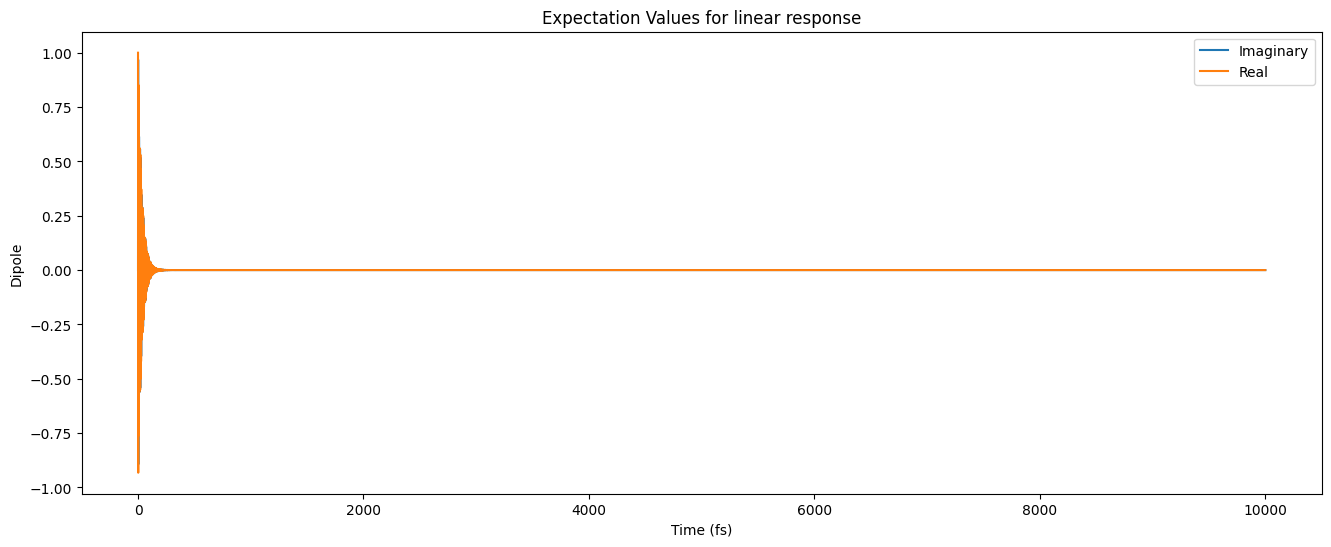

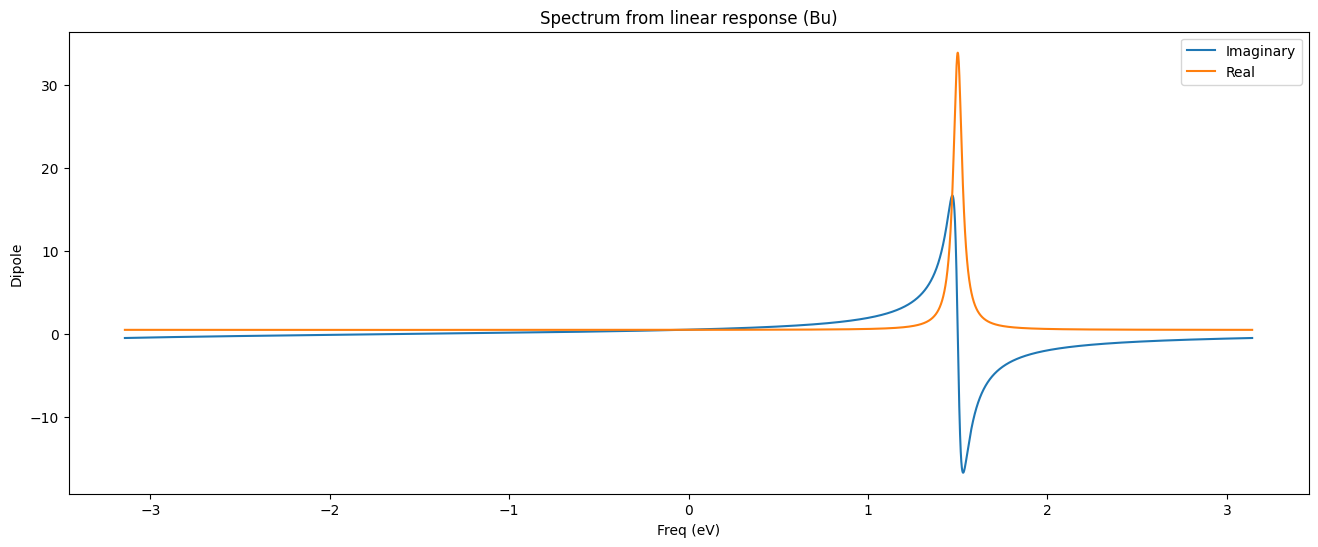

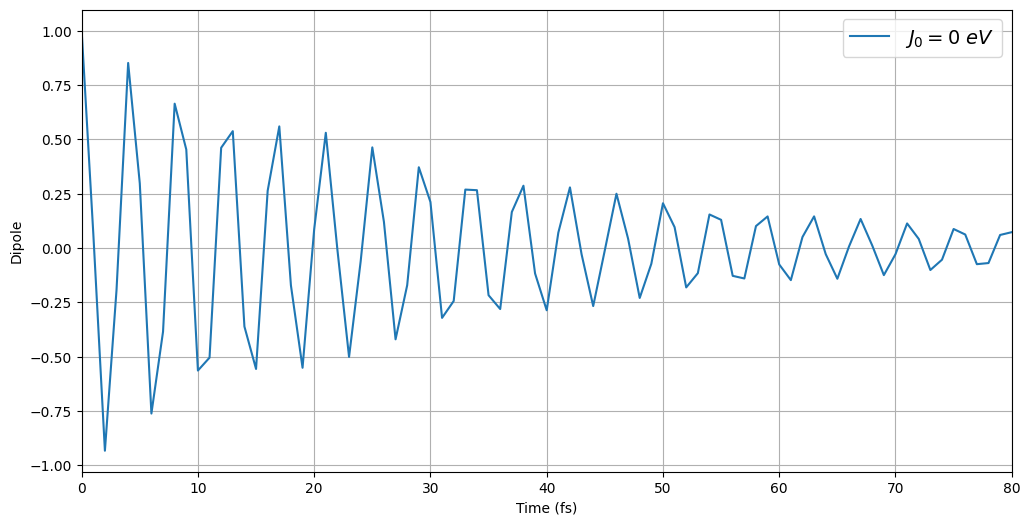

NameError: name 'Hd' is not defined

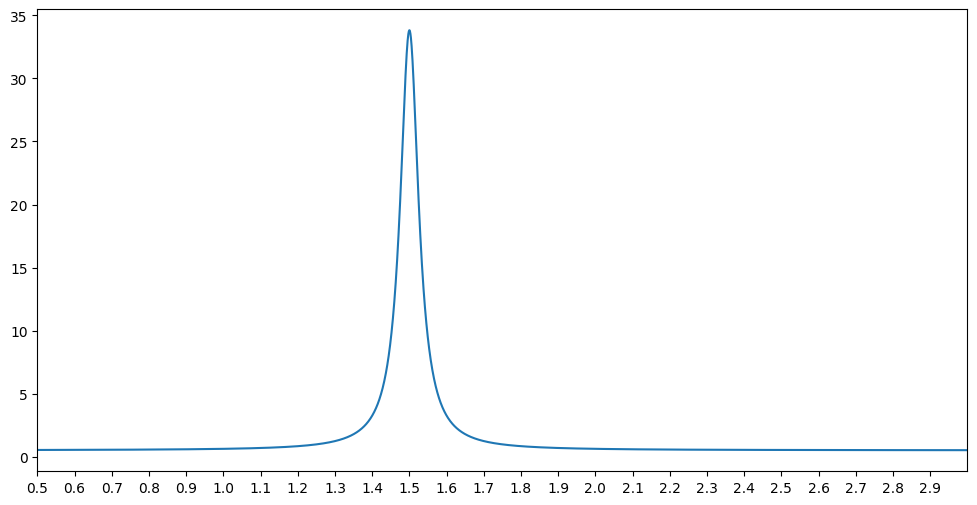

In [21]:
en,T = H_total.eigenstates()
print(en)
 
dipole, t_list, spec, freq = sys.linear_spec(10000, resolution=1)
 
plt.figure(figsize=(12, 6))
plt.plot(t_list, np.real(dipole), label = "$J_{0} = 0 \ eV$") #real part of the dipole
plt.xlim(0, 80)
plt.xlabel("Time (fs)")
plt.ylabel("Dipole")
plt.legend(fontsize=14)
plt.grid()
plt.show()
 
plt.figure(figsize=(12, 6))
plt.plot(freq, np.real(spec), label = "$J_{0} = 0 \ eV$") #real part of the spectrum
plt.xlim(0.5, 3.0)
plt.xticks(np.arange(0.5, 3.0, 0.1))
 
for i in Hd.eigenenergies():
  plt.axvline(x=i, color='red', linestyle='--')
 
plt.xlabel("Energy (eV)")
plt.ylabel("Spectrum")
plt.legend(fontsize=14)
plt.grid()
plt.show()

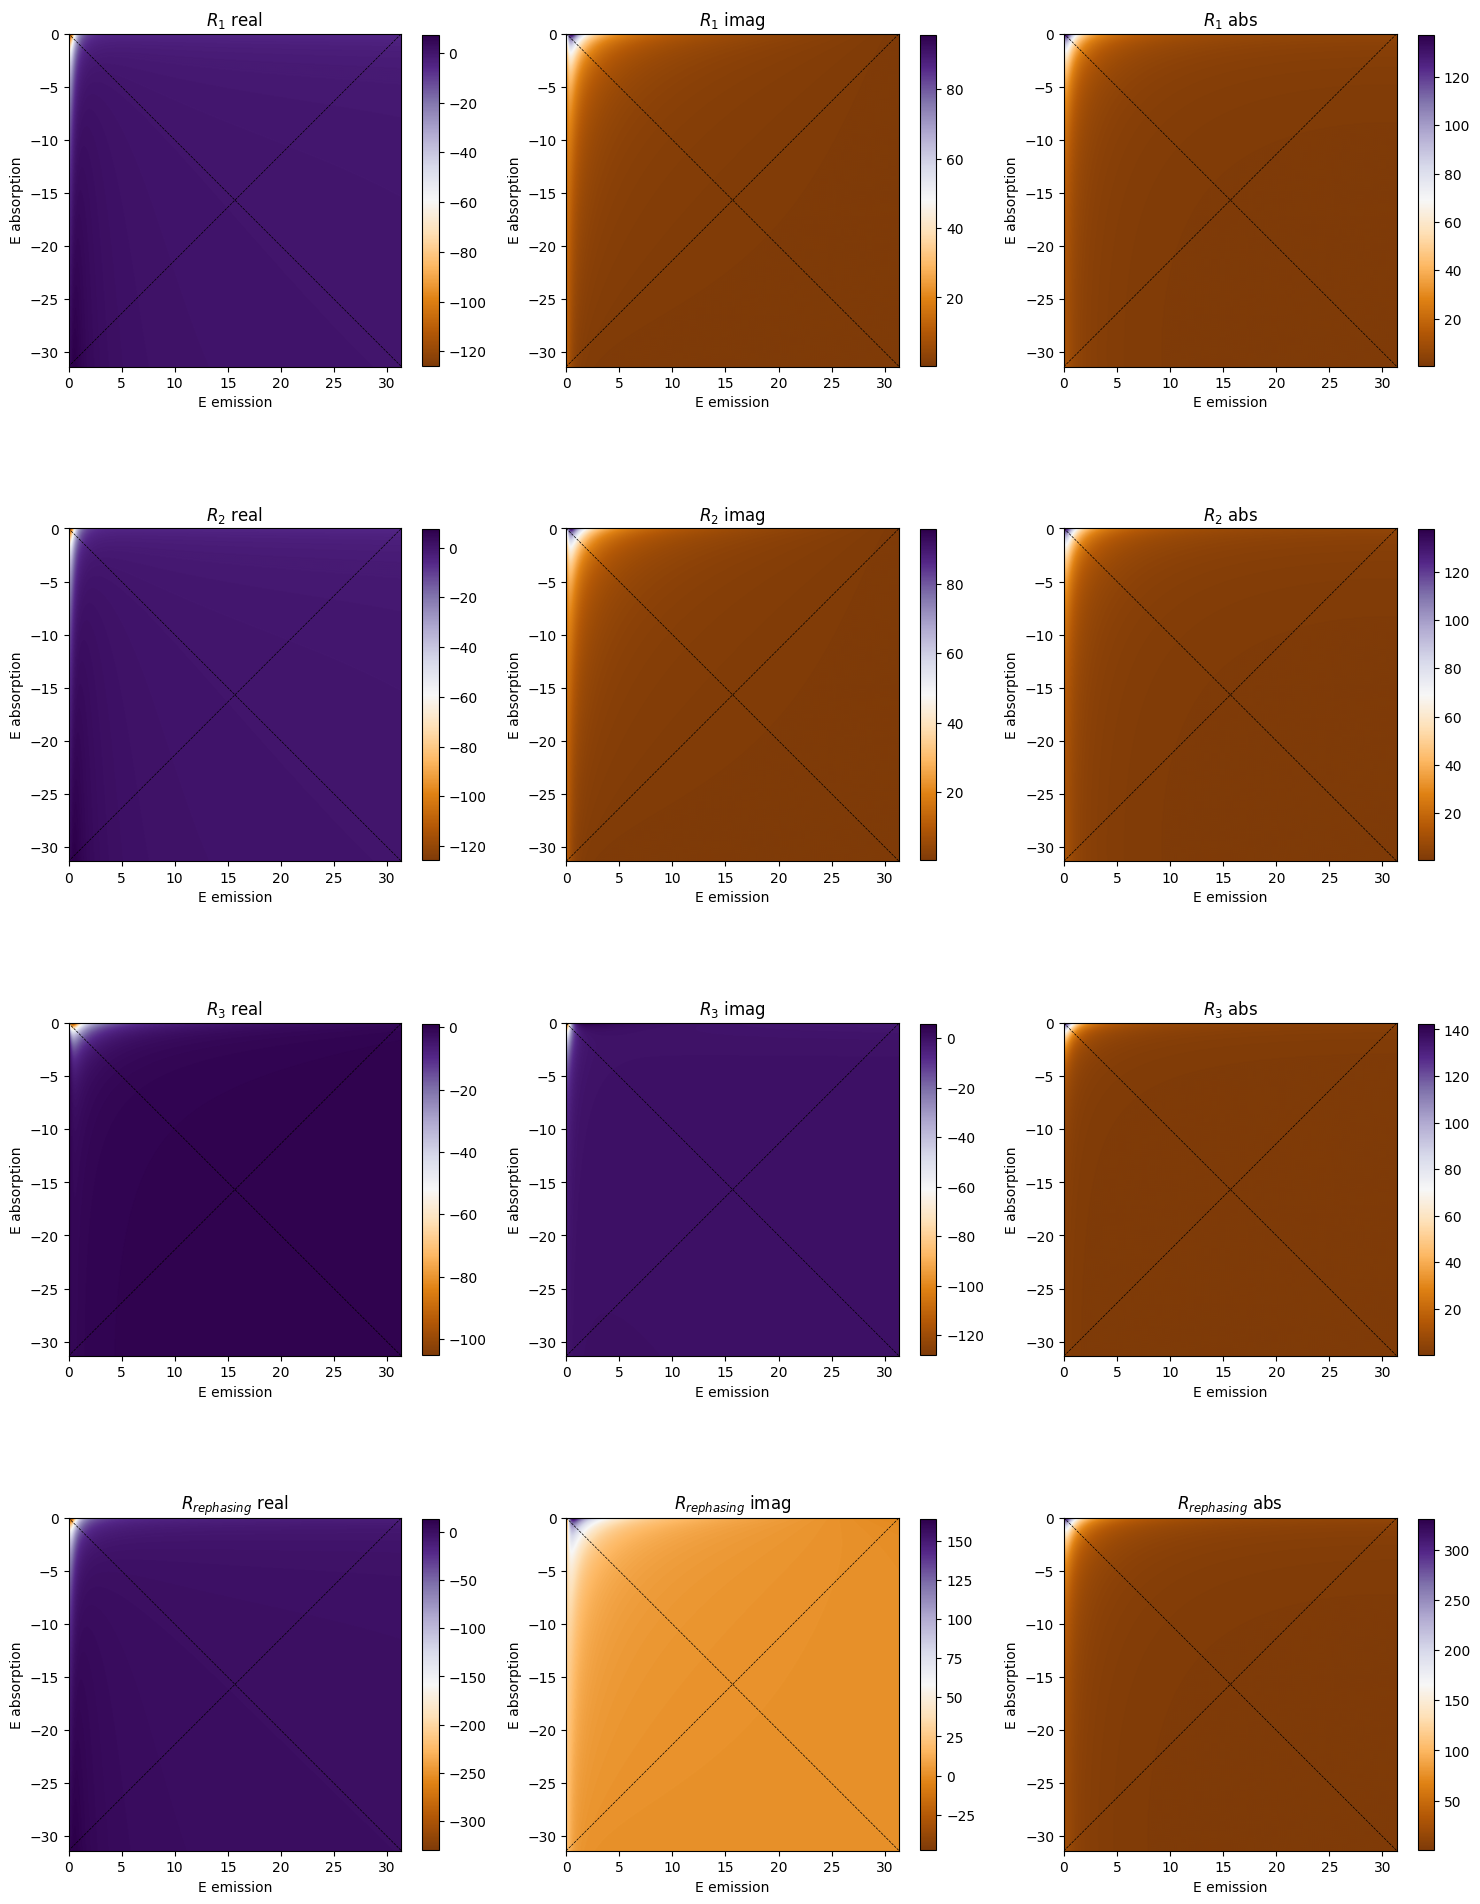

In [22]:
pf.silva_plot(rephasing_spectra, f1,f2, labels=['E emission', 'E absorption'],
              title_list=['$R_1$', '$R_2$', '$R_3$', '$R_{rephasing}$'], scale='linear', color_map='PuOr',
              interpolation='spline36', center_scale=False, plot_sum=False, plot_quadrant='4', invert_y=False,
              diagonals=[True, True])

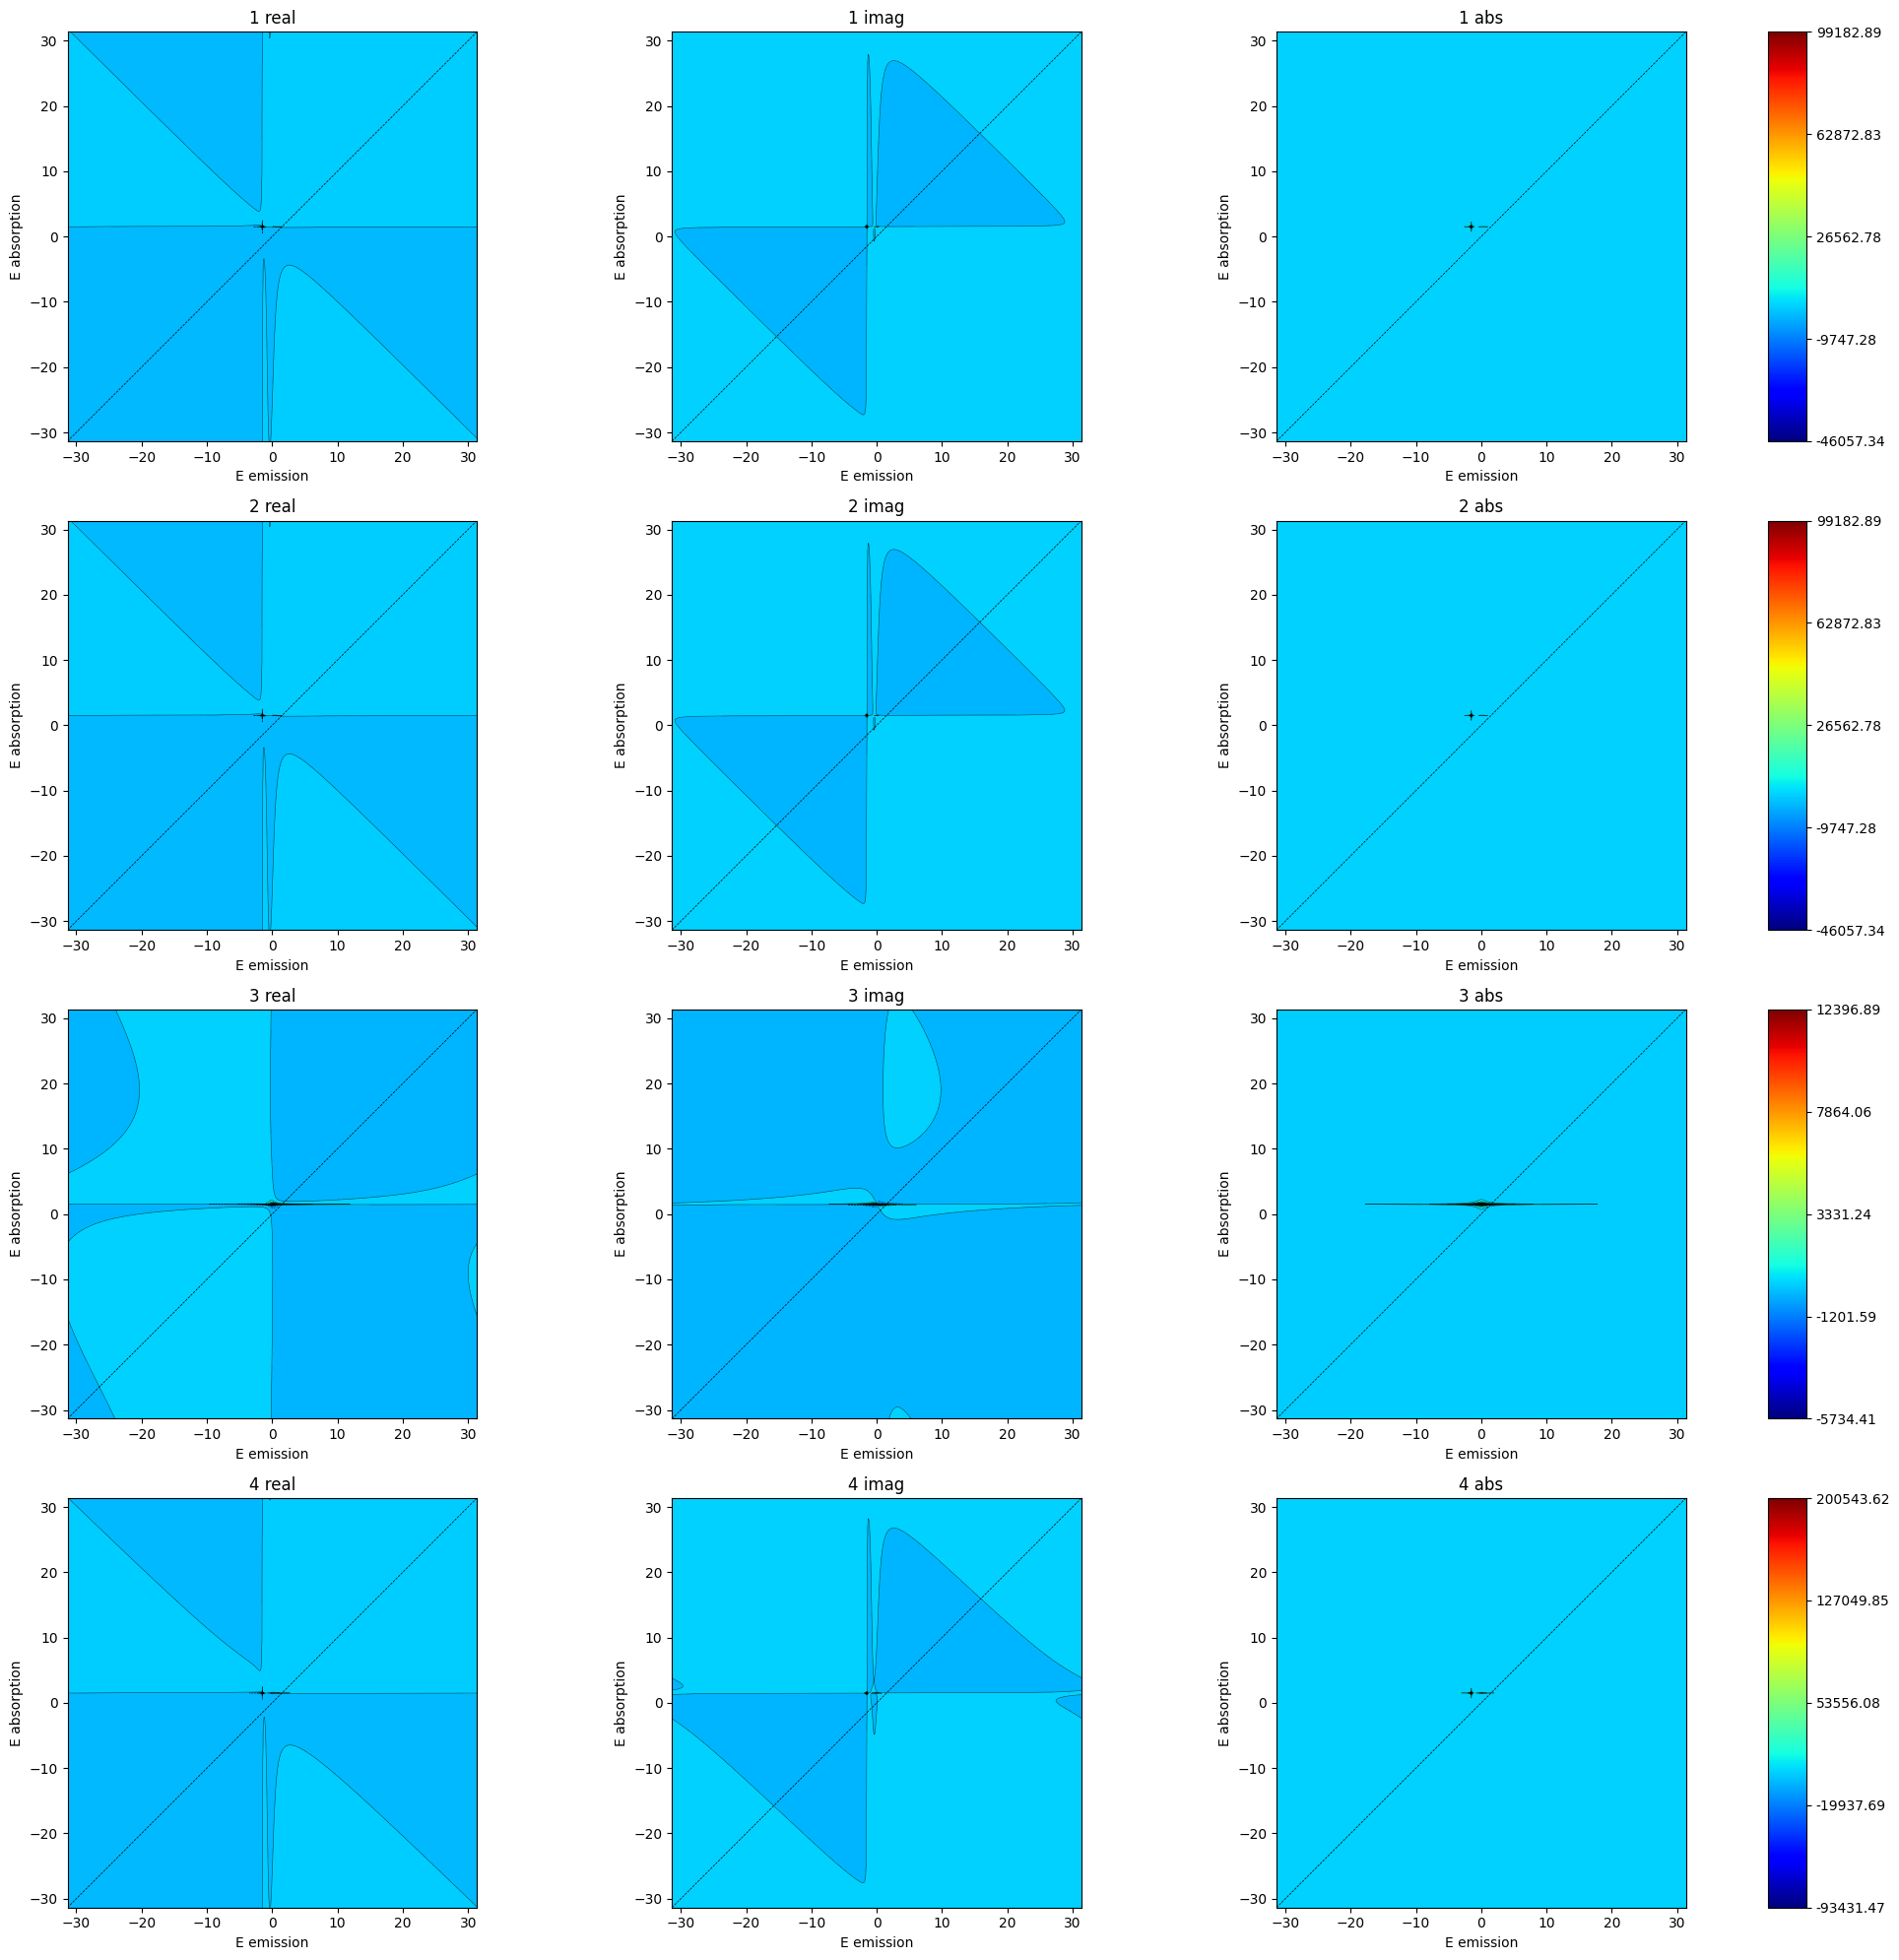

In [24]:
pf.silva_plot_contourf(rephasing_spectra, f1,f2, labels=['E emission', 'E absorption'],
              scale='linear', color_map='jet',
              center_scale=False, plot_sum=False, plot_quadrant="All", invert_y=False,
              diagonals=[False, True],nlevels=30,Zoom_coor=[0.9,1.3,0.9,1.3])